In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pymargins import Margins

rng = np.random.default_rng(42)
n = 2000
df = pd.DataFrame({
    "x": rng.normal(50, 10, n),
    "female": rng.binomial(1, 0.52, n),
})
lp = -1.5 + 0.03 * df["x"] - 0.3 * df["female"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm("y ~ x + female", data=df,
              family=sm.families.Binomial()).fit()
m = Margins.linear_scale(fit, at="overall")

In [2]:
# Full elasticity at the session's `at` setting
print(m.eyex("x").summary())

# Semi-elasticities
print(m.eydx("x").summary())
print(m.dyex("x").summary())

             Margins Result (delta, level=0.95)            
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
eyex(x)    0.8661   0.1357  6.3829  0.000    0.6001, 1.1320

n = 2000
κ: 0.020
             Margins Result (delta, level=0.95)            
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
eydx(x)    0.0175   0.0027  6.3829  0.000    0.0121, 0.0229

n = 2000
κ: 0.020


             Margins Result (delta, level=0.95)            
         estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
dyex(x)    0.3858   0.0597  6.4625  0.000    0.2688, 0.5028

n = 2000
κ: 0.020


In [3]:
# Elasticity of x within each level of female
print(m.eyex("x", over="female").summary())

             Margins Result (delta, level=0.95)             
         estimate  std err        z  P>|z|  [95% Conf. Int.]
------------------------------------------------------------
eyex(x)    0.7960   1.9850   0.4010  0.688   -3.0945, 4.6864
[1]        0.9429   0.0351  26.8333  0.000    0.8740, 1.0118

n = 2000
κ: max=0.042


In [4]:
x_bar = df["x"].mean()
y_bar = m.predict().estimate.item()

# eyex via scaled()
print(m.dydx("x").scaled(by=x_bar / y_bar).summary())

                    Margins Result (delta, level=0.95)                   
                       estimate  std err       z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------------
(x)*110.9958295306184    0.8661   0.1340  6.4625  0.000    0.6034, 1.1287

n = 2000
κ: 0.020
Delta-vs-sim disagreement: 6.420%


In [5]:
# Subgroup means for scaling
x_bar_0 = df.loc[df["female"] == 0, "x"].mean()
y_bar_0 = m.predict(atexog={"female": 0}).estimate.item()
x_bar_1 = df.loc[df["female"] == 1, "x"].mean()
y_bar_1 = m.predict(atexog={"female": 1}).estimate.item()

# Elasticity of x for female=0 and female=1
res_0 = m.dydx("x", atexog={"female": 0}).scaled(by=x_bar_0 / y_bar_0)
res_1 = m.dydx("x", atexog={"female": 1}).scaled(by=x_bar_1 / y_bar_1)

# Difference in elasticities with a proper SE
diff = res_1 - res_0
print(diff.summary())

                                            Margins Result (delta, level=0.95)                                            
                                                                        estimate  std err       z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------------------------------------------------------------------------
((female=1, x)*124.31135122094987) - ((female=0, x)*98.94062025641874)    0.1627   0.0177  9.1912  0.000    0.1280, 0.1974

n = 2000
κ: 0.029


[Text(0, 0.5, 'Elasticity of x')]

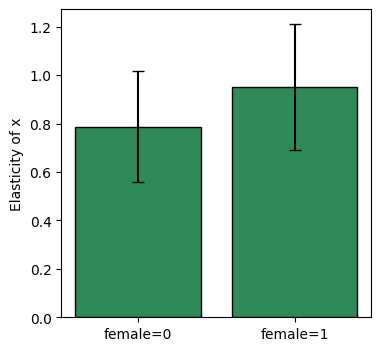

In [6]:
import matplotlib.pyplot as plt

df_0 = res_0.to_frame()
df_1 = res_1.to_frame()

labels = ["female=0", "female=1"]
estimates = [df_0["estimate"].iloc[0], df_1["estimate"].iloc[0]]
ci_lower = [df_0["ci_lower"].iloc[0], df_1["ci_lower"].iloc[0]]
ci_upper = [df_0["ci_upper"].iloc[0], df_1["ci_upper"].iloc[0]]

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(labels, estimates,
       yerr=[np.array(estimates) - np.array(ci_lower),
             np.array(ci_upper) - np.array(estimates)],
       capsize=4, color="seagreen", edgecolor="black")
ax.set(ylabel="Elasticity of x")